In [33]:
pip install xgboost

In [34]:
import pandas as pd

df = pd.read_csv(
    "../data/processed/model_ready_data.csv"
)

df.head()

,datetime,total_demand_kwh,hour,day,month,weekday,is_weekend,season,lag_1,lag_48,lag_96,rolling_mean_48,rolling_std_48
0,2013-01-03 00:00:00,209.864,0,3,1,3,0,0,243.522,198.338,220.013,240.736854,91.920733
1,2013-01-03 00:30:00,175.020,0,3,1,3,0,0,209.864,165.862,204.270,240.927646,91.771399
2,2013-01-03 01:00:00,151.394,1,3,1,3,0,0,175.020,147.971,189.439,240.998958,91.698930
3,2013-01-03 01:30:00,137.672,1,3,1,3,0,0,151.394,129.889,173.019,241.161104,91.504956
4,2013-01-03 02:00:00,128.217,2,3,1,3,0,0,137.672,117.542,154.537,241.383500,91.210616


In [35]:
features = [
    "hour",
    "day",
    "month",
    "weekday",
    "is_weekend",
    "season",
    "lag_1",
    "lag_48",
    "lag_96",
    "rolling_mean_48",
    "rolling_std_48"
]

X = df[features]

y = df["total_demand_kwh"]

In [36]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [37]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [38]:
df["datetime"] = pd.to_datetime(
    df["datetime"]
)

df = (
    df
    .sort_values("datetime")
    .reset_index(drop=True)
)

print("Dataset shape:", df.shape)
print("Start date:", df["datetime"].min())
print("End date:", df["datetime"].max())

Dataset shape: (20209, 13)
Start date: 2013-01-03 00:00:00
End date: 2014-02-28 00:00:00


In [39]:
required_columns = features + [
    "total_demand_kwh"
]

print(
    df[required_columns]
    .isnull()
    .sum()
)

df = df.dropna(
    subset=required_columns
).reset_index(drop=True)

hour                0
day                 0
month               0
weekday             0
is_weekend          0
season              0
lag_1               0
lag_48              0
lag_96              0
rolling_mean_48     0
rolling_std_48      0
total_demand_kwh    0
dtype: int64


In [40]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [41]:
xgb_predictions = xgb_model.predict(
    X_test
)

In [42]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(
    y_test,
    xgb_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_predictions
    )
)

r2 = r2_score(
    y_test,
    xgb_predictions
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 5.707997258687952
RMSE: 7.632832615295308
R²: 0.9911779095929943


In [43]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(
    y_test,
    xgb_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_predictions
    )
)

mape = (
    mean_absolute_percentage_error(
        y_test,
        xgb_predictions
    ) * 100
)

r2 = r2_score(
    y_test,
    xgb_predictions
)

print(f"MAE: {mae:.4f} kWh")
print(f"RMSE: {rmse:.4f} kWh")
print(f"MAPE: {mape:.4f}%")
print(f"R²: {r2:.6f}")

MAE: 5.7080 kWh
RMSE: 7.6328 kWh
MAPE: 2.5785%
R²: 0.991178


In [44]:
xgb_metrics = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "MAPE",
        "R2"
    ],
    "Value": [
        mae,
        rmse,
        mape,
        r2
    ]
})

display(xgb_metrics)

xgb_metrics.to_csv(
    "../outputs/tables/xgboost_metrics.csv",
    index=False
)

,Metric,Value
0,MAE,5.707997
1,RMSE,7.632833
2,MAPE,2.578478
3,R2,0.991178


In [45]:
from pathlib import Path

Path("../outputs/tables").mkdir(
    parents=True,
    exist_ok=True
)

Path("../outputs/figures").mkdir(
    parents=True,
    exist_ok=True
)

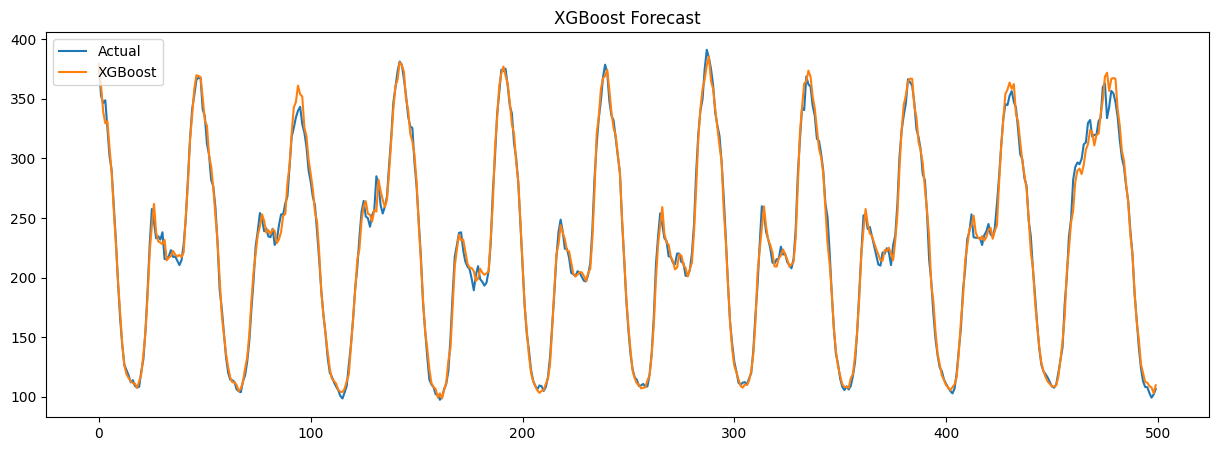

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    y_test.values[:500],
    label="Actual"
)

plt.plot(
    xgb_predictions[:500],
    label="XGBoost"
)

plt.legend()

plt.title(
    "XGBoost Forecast"
)

plt.show()

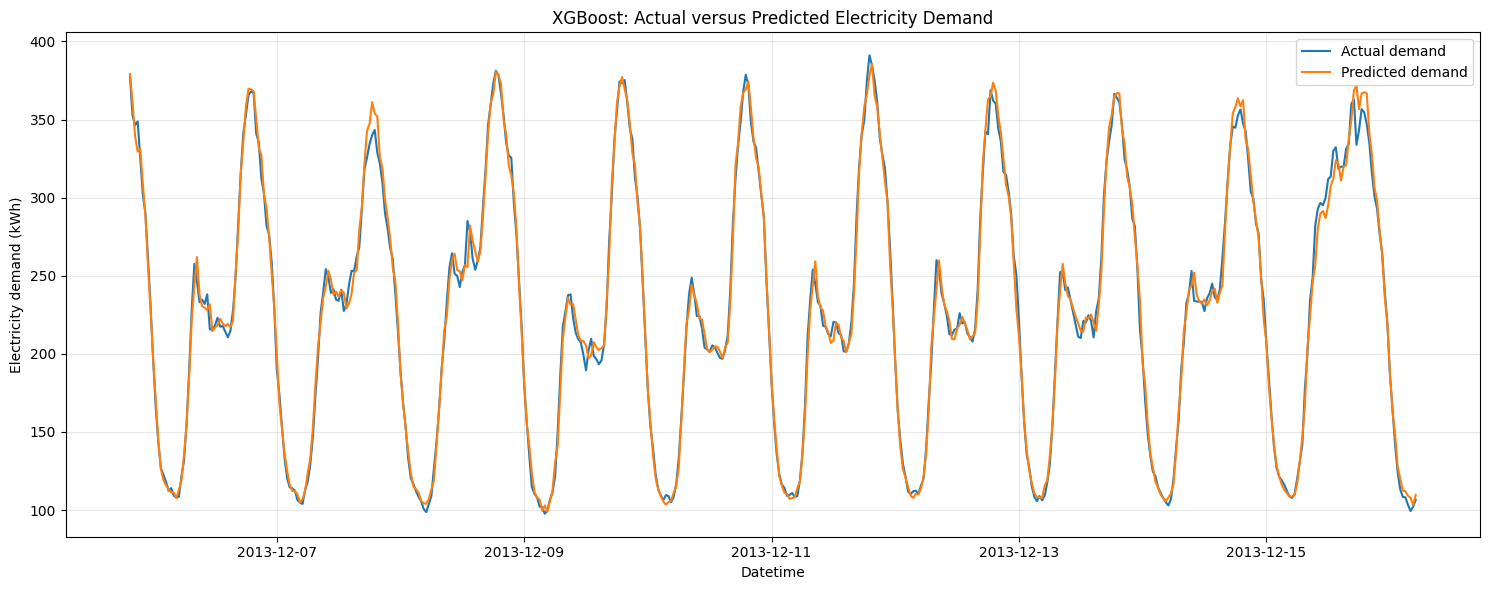

In [47]:
plot_size = min(
    500,
    len(y_test)
)

test_dates = df.loc[
    X_test.index,
    "datetime"
].iloc[:plot_size]

plt.figure(figsize=(15, 6))

plt.plot(
    test_dates,
    y_test.iloc[:plot_size],
    label="Actual demand",
    linewidth=1.5
)

plt.plot(
    test_dates,
    xgb_predictions[:plot_size],
    label="Predicted demand",
    linewidth=1.5
)

plt.xlabel("Datetime")
plt.ylabel("Electricity demand (kWh)")
plt.title(
    "XGBoost: Actual versus Predicted Electricity Demand"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../outputs/figures/xgboost_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [48]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_model.feature_importances_
})

importance = (
    importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

print(importance)

            Feature  Importance
6             lag_1    0.512351
7            lag_48    0.415761
8            lag_96    0.026679
0              hour    0.015211
4        is_weekend    0.011632
3           weekday    0.007454
9   rolling_mean_48    0.003209
5            season    0.002567
10   rolling_std_48    0.002221
2             month    0.001914
1               day    0.001002


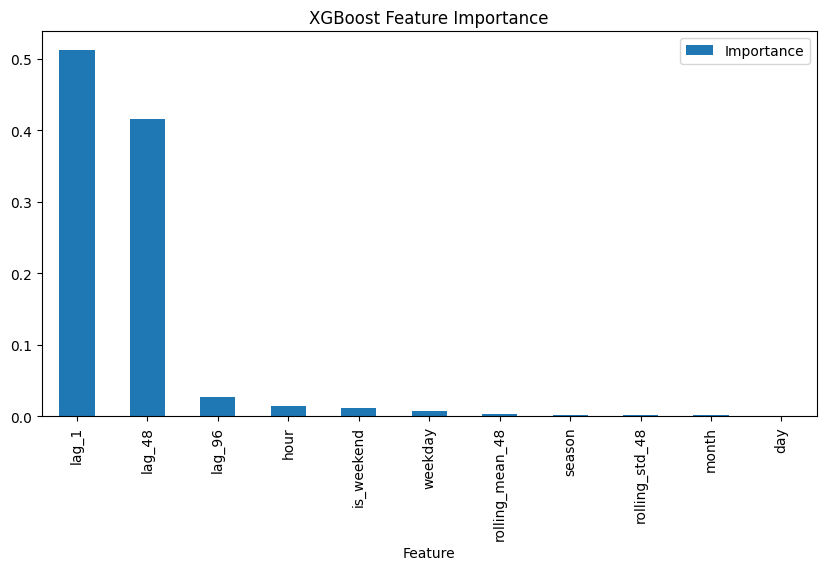

In [49]:
importance.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "XGBoost Feature Importance"
)

plt.show()

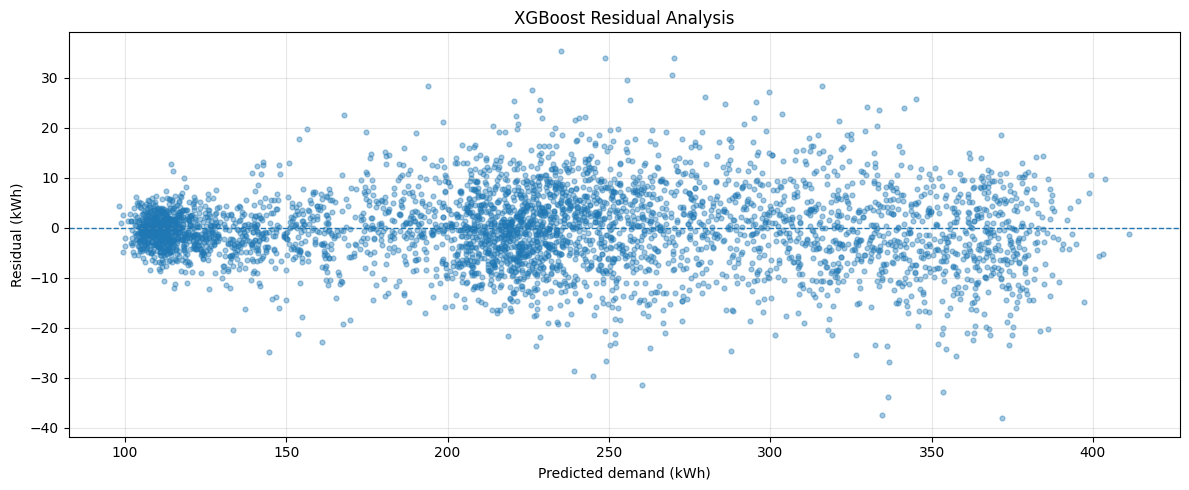

In [50]:
residuals = (
    y_test.to_numpy() -
    xgb_predictions
)

plt.figure(figsize=(12, 5))

plt.scatter(
    xgb_predictions,
    residuals,
    alpha=0.4,
    s=12
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Predicted demand (kWh)")
plt.ylabel("Residual (kWh)")
plt.title(
    "XGBoost Residual Analysis"
)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../outputs/figures/xgboost_residuals.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [51]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_model.feature_importances_
})

importance = (
    importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(importance)

importance.to_csv(
    "../outputs/tables/xgb_feature_importance.csv",
    index=False
)

,Feature,Importance
0,lag_1,0.512351
1,lag_48,0.415761
2,lag_96,0.026679
3,hour,0.015211
4,is_weekend,0.011632
5,weekday,0.007454
6,rolling_mean_48,0.003209
7,season,0.002567
8,rolling_std_48,0.002221
9,month,0.001914


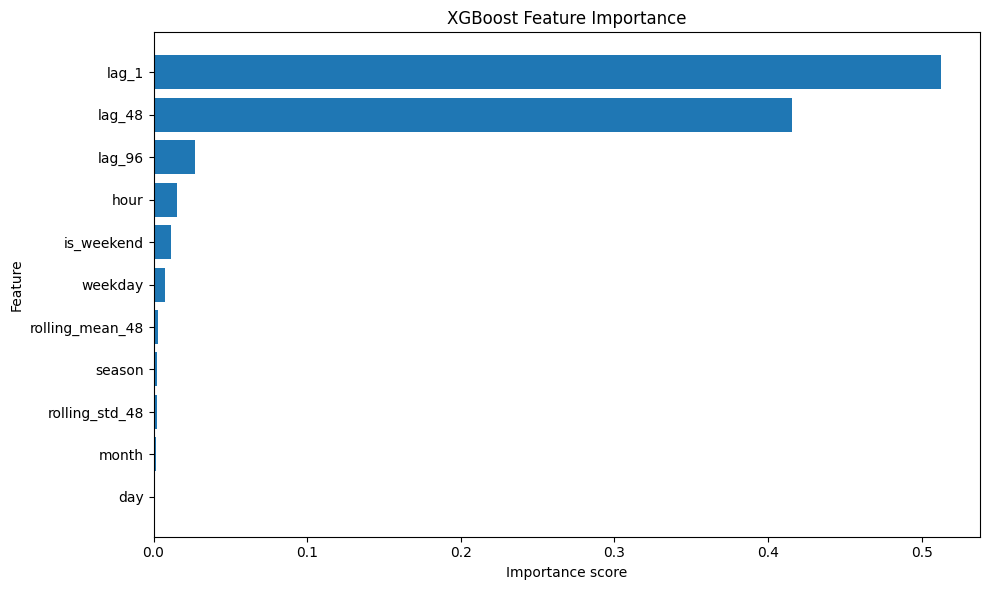

In [52]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance score")
plt.ylabel("Feature")
plt.title(
    "XGBoost Feature Importance"
)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/xgb_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [53]:
lr_results = pd.read_csv(
    "../outputs/tables/linear_regression_metrics.csv"
)

lr_mae = lr_results.loc[
    lr_results["Metric"] == "MAE",
    "Value"
].iloc[0]

lr_rmse = lr_results.loc[
    lr_results["Metric"] == "RMSE",
    "Value"
].iloc[0]

lr_mape = lr_results.loc[
    lr_results["Metric"] == "MAPE",
    "Value"
].iloc[0]

lr_r2 = lr_results.loc[
    lr_results["Metric"].isin(
        ["R2", "R²"]
    ),
    "Value"
].iloc[0]

In [54]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "XGBoost"
    ],
    "MAE": [
        lr_mae,
        mae
    ],
    "RMSE": [
        lr_rmse,
        rmse
    ],
    "MAPE": [
        lr_mape,
        mape
    ],
    "R2": [
        lr_r2,
        r2
    ]
})

display(comparison)

comparison.to_csv(
    "../outputs/tables/model_comparison.csv",
    index=False
)

,Model,MAE,RMSE,MAPE,R2
0,Linear Regression,10.745464,13.777718,5.029936,0.971256
1,XGBoost,5.707997,7.632833,2.578478,0.991178


In [55]:
train_dates = df["datetime"].iloc[:split_index]
test_dates = df["datetime"].iloc[split_index:]

print("Training period:")
print(train_dates.min(), "to", train_dates.max())

print("\nTesting period:")
print(test_dates.min(), "to", test_dates.max())

assert train_dates.max() < test_dates.min()

Training period:
2013-01-03 00:00:00 to 2013-12-05 19:00:00

Testing period:
2013-12-05 19:30:00 to 2014-02-28 00:00:00


In [56]:
objective="reg:squarederror",
n_jobs=-1

In [57]:
from pathlib import Path

Path("../outputs/tables").mkdir(
    parents=True,
    exist_ok=True
)

Path("../outputs/figures").mkdir(
    parents=True,
    exist_ok=True
)

In [58]:
df["datetime"] = pd.to_datetime(
    df["datetime"]
)

df = (
    df
    .sort_values("datetime")
    .reset_index(drop=True)
)

In [59]:
import pandas as pd

df = pd.read_csv(
    "../data/processed/model_ready_data.csv"
)

df["datetime"] = pd.to_datetime(
    df["datetime"]
)

df = (
    df
    .sort_values("datetime")
    .reset_index(drop=True)
)

print("Dataset shape:", df.shape)
print("Start date:", df["datetime"].min())
print("End date:", df["datetime"].max())

Dataset shape: (20209, 13)
Start date: 2013-01-03 00:00:00
End date: 2014-02-28 00:00:00


In [60]:
X = df[features]
y = df["total_demand_kwh"]

In [62]:
type(xgb_model)

xgboost.sklearn.XGBRegressor

In [63]:
from pathlib import Path
import json

model_directory = Path("../models")
model_directory.mkdir(parents=True, exist_ok=True)

xgb_model.save_model(
    model_directory / "xgboost_demand_model.json"
)

features = [
    "hour",
    "day",
    "month",
    "weekday",
    "is_weekend",
    "season",
    "lag_1",
    "lag_48",
    "lag_96",
    "rolling_mean_48",
    "rolling_std_48"
]

with open(
    model_directory / "feature_names.json",
    "w"
) as file:
    json.dump(features, file, indent=4)

print("✅ Model saved successfully.")

✅ Model saved successfully.
